# Практика 1: Введение в трансформеры

Трансформеры — это архитектура, основанная на механизме внимания, которая широко используется для обработки последовательных данных, таких как текст. Начнём с установки необходимых библиотек:  
`pip install torch transformers datasets`.  
Далее загружаем датасет, например, `IMDB` для анализа тональности. Используем `AutoTokenizer от Hugging Face` для токенизации текста в числовые представления. Затем инициализируем предобученную модель `AutoModelForSequenceClassification`, которая содержит слои трансформера. Разделяем данные на обучающую и тестовую выборки, создаём `DataLoader` для подачи данных в модель. Определяем `функцию потерь (CrossEntropyLoss)` и `оптимизатор (AdamW)`. Используем `Trainer от Hugging Face` или пишем цикл градиентного спуска вручную. Запускаем обучение, оцениваем качество модели на тестовой выборке.   
Анализируем потери и точность, пробуем различные предобученные модели, такие как `bert-base-uncased` или `distilbert-base-uncased`, сравниваем результаты.

In [25]:
from datasets import load_dataset

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoTokenizer,
    DataCollatorWithPadding,
    AutoModelForSequenceClassification,
    set_seed,
)

import matplotlib.pyplot as plt

import pandas as pd

from tqdm.auto import tqdm
import time

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [2]:
torch.cuda.empty_cache()

In [3]:
def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"Время обучения {end - start:.2f} сек")
        return result
    return wrapper

In [4]:
def data_processing(model_name="distilbert-base-uncased", max_length=256, train_size=1000, test_size=200):    
    
    dataset = load_dataset("imdb")
    dataset['train'] = dataset['train'].select(range(train_size))
    dataset['test'] = dataset['test'].select(range(test_size))
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    tokenized_datasets = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=["text"]
    )

    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

    tokenized_datasets.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )

    return tokenized_datasets, tokenizer

In [5]:
@timer
def train_model(model, train_loader, val_loader, epochs, lr, device="cpu"):
    history = []

    scaler = GradScaler(enabled=(str(device).startswith("cuda")))
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loss_f = nn.CrossEntropyLoss()
    model.to(device)

    for epoch in range(epochs):
        model.train()

        train_loss_sum = 0.0
        train_batches = 0

        progress_bar_lr = tqdm(train_loader, desc=f"Train", leave=False)
        for batch in progress_bar_lr:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                loss = loss_f(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * labels.size(0)
            train_batches += labels.size(0)

            progress_bar_lr.set_postfix({
                "epoch" : f"{epoch + 1}/{epochs}",
                "batch_loss": f"{loss.item():.4f}"
            })

        avg_train_loss = train_loss_sum / max(train_batches, 1)
        
        model.eval()
        val_loss_sum = 0.0
        total_correct = 0
        total_samples = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                loss = loss_f(logits, labels)
                preds = logits.argmax(dim=1)

                val_loss_sum += loss.item() * labels.size(0)
                total_correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        avg_val_loss = val_loss_sum / max(total_samples, 1)
        val_acc = total_correct / max(total_samples, 1)

        history.append({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": val_acc
        })

    return history

In [6]:
def plot_history(history):
    epochs = [h["epoch"] + 1 for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss = [h["val_loss"] for h in history]
    val_acc = [h["val_accuracy"] for h in history]

    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(epochs, train_loss, label="Train Loss")
    ax1.plot(epochs, val_loss, label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    ax2 = ax1.twinx()
    ax2.plot(epochs, val_acc, linestyle="--", label="Val Accuracy")
    ax2.set_ylabel("Accuracy")

    fig.legend(loc="upper right")
    plt.title("Training History")

    plt.show()

---
### distilbert-base-uncased

In [7]:
epochs = 15

In [8]:
dataset, tokenizer = data_processing()
dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
    unsupervised: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# model.load_state_dict(torch.load('prac1_bert_model.pth'))

batch_size = 32
collator = DataCollatorWithPadding(tokenizer)
train_loader = DataLoader(dataset['train'], batch_size=batch_size, shuffle=True, collate_fn=collator)
val_loader = DataLoader(dataset['test'], batch_size=batch_size, shuffle=False, collate_fn=collator)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9092.95it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    lr=2e-5,
    device=device
)

C:\Users\semen\AppData\Local\Temp\ipykernel_2656\335101481.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(str(device).startswith("cuda")))
Train:   0%|          | 0/32 [00:00<?, ?it/s]C:\Users\semen\AppData\Local\Temp\ipykernel_2656\335101481.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Время обучения 1178.90 сек


---

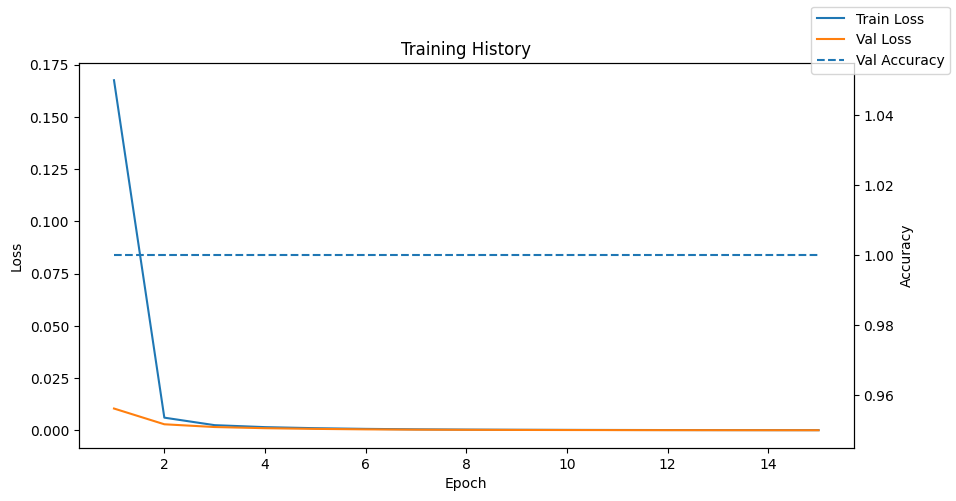

In [11]:
plot_history(history)

In [26]:
df_1 = pd.DataFrame(history)
df_1

,epoch,train_loss,val_loss,val_accuracy
0,0,0.167548,0.010439,1.0
1,1,0.006072,0.002902,1.0
2,2,0.002475,0.001586,1.0
3,3,0.001535,0.001026,1.0
4,4,0.001027,0.000698,1.0
5,5,0.000701,0.000472,1.0
6,6,0.000485,0.000334,1.0
7,7,0.000357,0.000249,1.0
8,8,0.000275,0.000192,1.0
9,9,0.000217,0.000153,1.0


In [ ]:
torch.save(model.state_dict(), 'prac1_distilbert_model.pth')

---
### bert-base-uncased

In [13]:
dataset_2, tokenizer_2 = data_processing(model_name="bert-base-uncased")
dataset_2

'[WinError 10061] Подключение не установлено, т.к. конечный компьютер отверг запрос на подключение' thrown while requesting HEAD https://huggingface.co/datasets/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\semen\.cache\huggingface\datasets\imdb\plain_text\0.0.0\e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Sat Mar 14 23:04:53 2026).


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
    unsupervised: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [ ]:
model_2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# model_2.load_state_dict(torch.load('prac1_distilbert_model.pth'))

batch_size = 32
collator = DataCollatorWithPadding(tokenizer_2)
train_loader_2 = DataLoader(dataset_2['train'], batch_size=batch_size, shuffle=True, collate_fn=collator)
val_loader_2 = DataLoader(dataset_2['test'], batch_size=batch_size, shuffle=False, collate_fn=collator)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11001.42it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

In [15]:
history_2 = train_model(
    model=model_2,
    train_loader=train_loader_2,
    val_loader=val_loader_2,
    epochs=epochs,
    lr=2e-5,
    device=device
)

C:\Users\semen\AppData\Local\Temp\ipykernel_2656\335101481.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(str(device).startswith("cuda")))
Train:   0%|          | 0/32 [00:00<?, ?it/s]C:\Users\semen\AppData\Local\Temp\ipykernel_2656\335101481.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Время обучения 23208.67 сек


---

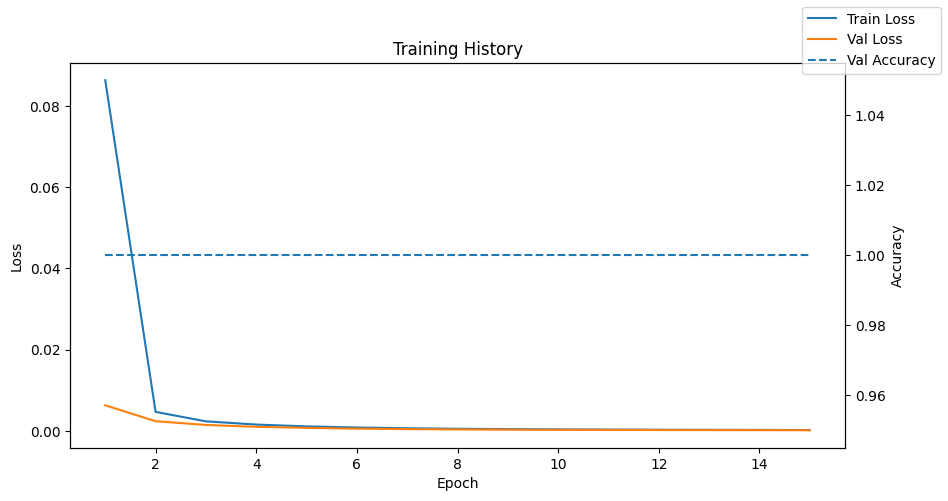

In [16]:
plot_history(history_2)

In [27]:
df_2 = pd.DataFrame(history_2)
df_2

,epoch,train_loss,val_loss,val_accuracy
0,0,0.086405,0.006252,1.0
1,1,0.004629,0.002338,1.0
2,2,0.002303,0.001412,1.0
3,3,0.001507,0.000955,1.0
4,4,0.001053,0.000684,1.0
5,5,0.000784,0.000502,1.0
6,6,0.000599,0.000384,1.0
7,7,0.000474,0.000307,1.0
8,8,0.000380,0.000251,1.0
9,9,0.000320,0.000211,1.0


In [22]:
torch.save(model_2.state_dict(), 'prac1_bert_model.pth')